# Traitement des données d'oculométrie

Ce notebook illustre le pipeline de traitement des données d'oculométrie.

## 1. Paths

### Root folder

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))
print(ROOT)

/Users/noe-edouard/Desktop/ETUDES/INP/Stages/3A/Code


### Importations

In [2]:
from pathlib import Path
from collections.abc import Sequence

import pandas as pd

from processing.parser import Parser
from processing.extractor import Extractor
from processing.profiler import Profiler
from processing.cleaner import Cleaner
from saliency.centerbias import build_centerbias
from helpers.loader import Loader

## 2. Process data

### Processing function

In [3]:
def process_data(modality: str, root_dir: str | Path):
    
    # PATHS
    asc_dir = root_dir / Path(f"asc/{modality}/")
    images_dir = root_dir / Path(f"images/{modality}/")
    dataframes_dir = root_dir / Path(f"dataframes/{modality}")
    maps_dir = root_dir / Path(f"maps/{modality}")
    metadata_path = root_dir / Path("metadata/metadata.json")

    # EXTRACTION
    loader = Loader(metadata_path)
    parser = Parser(loader.metadata)
    extractor = Extractor(parser)

    print("\n\n########## EXTRACTION ##########")
    raw_fixations_df, raw_blinks_df, raw_summary_df = extractor.run(
        asc_dir=asc_dir,
        modality=modality,
        verbose=True,
        save=True,
        output_dir=dataframes_dir / 'raw'
    )

    # ANALYSIS
    profiler = Profiler(
        min_fix_duration=80,
        max_blinks_valid=4,
        center_tolerance_deg=2.0,
    )

    print("\n\n########## PROFILING ##########")
    trial_summary_df, participant_summary_df, invalid_trials_df = profiler.run(
        summary_df=raw_summary_df,
        fixations_df=raw_fixations_df,
        blinks_df=raw_blinks_df,
        verbose=True,
        save=True,
        output_dir=dataframes_dir / 'analysis'
    )


    # CLEANING
    cleaner = Cleaner(
        min_fix_duration=80,
        keep_only_inside_screen=True,
    )

    print("\n\n########## CLEANING ##########")
    clean_fixations_df, clean_summary_df = cleaner.run(
        raw_fixations_df=raw_fixations_df,
        trial_summary_df=trial_summary_df,
        verbose=True,
        save=True,
        output_dir=dataframes_dir / 'clean'
    )


### Infrared

In [4]:
root_dir = ROOT / Path('data/2026/global')
process_data("infrared", root_dir)



########## EXTRACTION ##########


Processing participants: 100%|██████████| 45/45 [00:01<00:00, 25.35it/s]



----- GENERAL -----
Participants: 45
Trials: 11241
Images uniques: 500
Fixations: 101064
Blinks: 5236

----- FIXATIONS PER TRIAL -----
Moyenne: 9.05
Std: 2.16
Min: 1
Max: 21

----- BLINKS PER TRIAL -----
Moyenne: 1.46
Std: 0.78
Min: 1
Max: 6

----- FIXATIONS DURATION (ms) -----
Moyenne: 315.46
Std: 240.79
Min: 1
Max: 4260


########## PROFILING ##########


Profiling trials: 100%|██████████| 11241/11241 [01:01<00:00, 183.49it/s]



----- GLOBAL -----
Trials: 11241
Invalid trials: 1229 (10.93%)
Blink per trial (mean): 0.47
Blink per trial (std):  0.81
Total fixations (mean): 8.99
Total fixations (std):  2.27
Total fixations (mean): 8.99
Valid fixations (std):  2.20
Not centered: 1149 (10.22%)

----- DISTANCES -----
Centre distance (mean): 155.76
Centre distance (std): 92.21
Successive distance (mean): 142.87
Successive distance (std): 103.87

----- INVALIDITY -----
invalid_reasons
first_fixation_not_centered                                                       1027
no_fixation                                                                         71
insufficient_number_of_fixations                                                    66
first_fixation_not_centered;insufficient_number_of_fixations                        40
too_many_blinks                                                                     14
first_fixation_not_centered;no_valid_fixation;insufficient_number_of_fixations       7
too_many_blinks;firs

### Visible

In [5]:
root_dir = ROOT / Path('data/2026/global')
process_data("visible", root_dir)



########## EXTRACTION ##########


Processing participants: 100%|██████████| 23/23 [00:00<00:00, 24.35it/s]



----- GENERAL -----
Participants: 23
Trials: 3450
Images uniques: 150
Fixations: 32843
Blinks: 1398

----- FIXATIONS PER TRIAL -----
Moyenne: 9.54
Std: 2.05
Min: 1
Max: 19

----- BLINKS PER TRIAL -----
Moyenne: 1.24
Std: 0.50
Min: 1
Max: 4

----- FIXATIONS DURATION (ms) -----
Moyenne: 300.93
Std: 226.32
Min: 16
Max: 3420


########## PROFILING ##########


Profiling trials: 100%|██████████| 3450/3450 [00:10<00:00, 340.93it/s]



----- GLOBAL -----
Trials: 3450
Invalid trials: 347 (10.06%)
Blink per trial (mean): 0.41
Blink per trial (std):  0.65
Total fixations (mean): 9.52
Total fixations (std):  2.10
Total fixations (mean): 9.52
Valid fixations (std):  2.02
Not centered: 329 (9.54%)

----- DISTANCES -----
Centre distance (mean): 160.62
Centre distance (std): 99.61
Successive distance (mean): 142.53
Successive distance (std): 109.98

----- INVALIDITY -----
invalid_reasons
first_fixation_not_centered                                     316
insufficient_number_of_fixations                                 18
no_fixation                                                       8
first_fixation_not_centered;insufficient_number_of_fixations      5
Name: count, dtype: int64


########## CLEANING ##########

----- TRIALS -----
Trials (raw):     3442
Trials (valid):   3103
Trials (invalid): 347

----- FIXATIONS -----
Raw fixations:   32843
Clean fixations: 26001
Keeping rate: 79.17%

----- PER IMAGE -----

Analysed imag

## 3. Sort data

### Sort function

In [6]:
root_dir = ROOT / Path('data/2026/')

In [7]:
def filter_stems(
    input_path: str | Path,
    output_path: str | Path,
    min_stem: int = 1,
    max_stem: int = 150,
    include_stems: Sequence[int | str] | None = None,
    exclude_stems: Sequence[int | str] | None = None,
) -> pd.DataFrame:

    input_path = Path(input_path)
    output_path = Path(output_path)

    df = pd.read_csv(input_path)

    stems = pd.to_numeric(df["image_stem"], errors="coerce")

    # Sélection de l'intervalle principal
    mask = stems.between(
        min_stem,
        max_stem,
        inclusive="both",
    )

    # Ajout éventuel d'images situées hors de l'intervalle
    if include_stems is not None:
        normalized_include_stems = (
            pd.to_numeric(
                pd.Series(include_stems),
                errors="coerce",
            )
            .dropna()
            .unique()
        )

        mask = mask | stems.isin(normalized_include_stems)

    # Exclusion éventuelle de certaines images
    if exclude_stems is not None:
        normalized_exclude_stems = (
            pd.to_numeric(
                pd.Series(exclude_stems),
                errors="coerce",
            )
            .dropna()
            .unique()
        )

        mask = mask & ~stems.isin(normalized_exclude_stems)

    filtered_df = df.loc[mask].copy()

    output_path.parent.mkdir(parents=True, exist_ok=True)
    filtered_df.to_csv(output_path, index=False)

    return filtered_df

### Visible

In [8]:
# 150 images
visible_fixation_input  = root_dir / 'global' / 'dataframes' / 'visible' / 'clean' / 'fixations.csv'
visible_fixation_output  = root_dir / 'paired' / 'dataframes' / 'fixations_visible.csv'

visible_df = filter_stems(
    input_path=visible_fixation_input,
    output_path=visible_fixation_output
)

### Infrared

In [9]:
# 150 images
infrared_fixation_input = root_dir / 'global' / 'dataframes' / 'infrared' / 'clean' / 'fixations.csv'
infrared_fixation_output = root_dir / 'paired' / 'dataframes' / 'fixations_infrared.csv'

infrared_df = filter_stems(
    input_path=infrared_fixation_input,
    output_path=infrared_fixation_output
)

In [10]:
# 500 images
infrared_fixation_input = root_dir / 'global' / 'dataframes' / 'infrared' / 'clean' / 'fixations.csv'
full_infrared_fixation_output = root_dir / 'single' / 'fixations.csv'

full_infrared_df = filter_stems(
    input_path=infrared_fixation_input,
    output_path=full_infrared_fixation_output,
    min_stem=1,
    max_stem=500,
    exclude_stems=["484", "485"],
)

---

## 4. Build Centerbiases

### Kernel size

In [11]:
from math import tan, pi

# Params
dist_screen_cm = 70              # Distance eye-to-screen (cm)
screen_size_cm = 53.1            # Screen height/width (cm)
screen_size_px = 1360            # Vertical/horizontal screen resolution (px)
stimuli_displayed_size_px = 600  # Displayed size (px)
stimuli_real_size_px = 470       # Real size (px)

# Size corresponding to 1 dva in real world
size_1dva_cm = 2 * dist_screen_cm * tan(0.5 * pi / 180)

# Screen pixels per degree
pixels_per_dva_screen = size_1dva_cm / (screen_size_cm / screen_size_px)

# Stimuli pixel per degree
scale_factor = stimuli_real_size_px / stimuli_displayed_size_px
pixels_per_dva_real = pixels_per_dva_screen * scale_factor

print(f"Scale factor = {scale_factor:.3f}")
print(f"1 dva = {pixels_per_dva_screen:.2f} pixels in screen space")
print(f"1 dva = {pixels_per_dva_real:.2f} pixels in stimuli space")

Scale factor = 0.783
1 dva = 31.29 pixels in screen space
1 dva = 24.51 pixels in stimuli space


### Paired Dataset

In [12]:
# Full
centerbias_paired_full = build_centerbias(
    fixation_sources=[
        visible_df,
        infrared_df,
    ],
    output_path=root_dir / 'paired' / 'centerbias' / 'full.npy',
    template_shape=(1024, 1024),
    sigma=25,
)

# Visible
centerbias_paired_visible = build_centerbias(
    fixation_sources=[
        visible_df,
    ],
    output_path=root_dir / 'paired' / 'centerbias' / 'visible.npy',
    template_shape=(1024, 1024),
    sigma=25,
)

# Infrared
centerbias_paired_infrared = build_centerbias(
    fixation_sources=[
        infrared_df,
    ],
    output_path=root_dir / 'paired' / 'centerbias' / 'infrared.npy',
    template_shape=(1024, 1024),
    sigma=25,
)

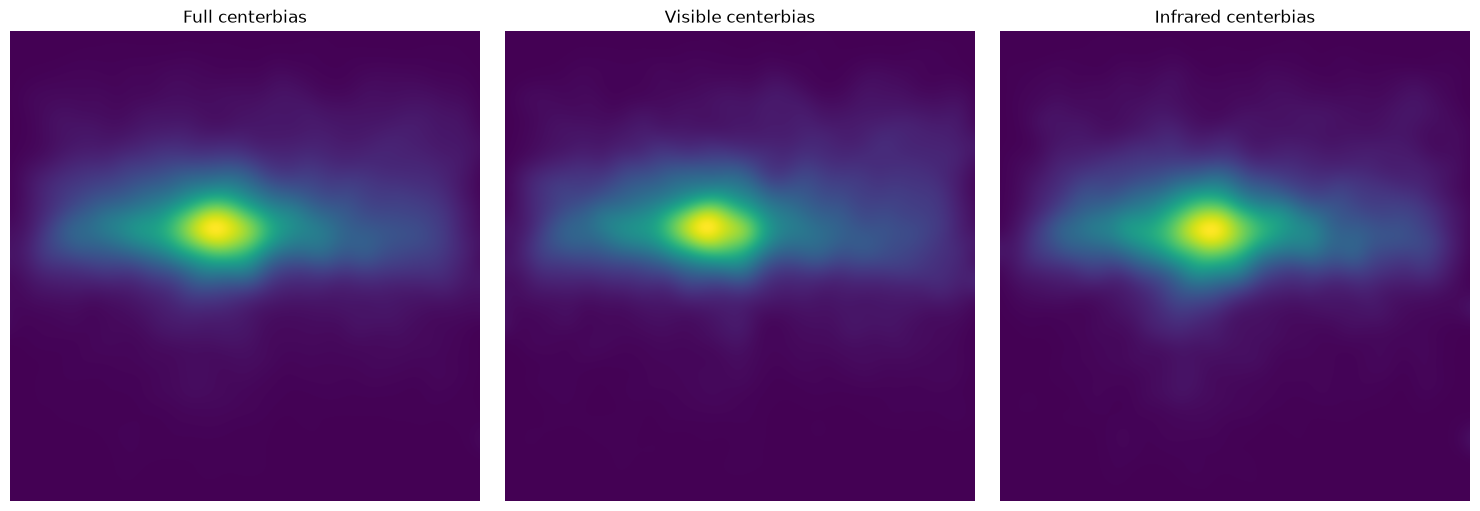

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(centerbias_paired_full)
axes[0].set_title("Full centerbias")
axes[0].axis("off")

axes[1].imshow(centerbias_paired_visible)
axes[1].set_title("Visible centerbias")
axes[1].axis("off")

axes[2].imshow(centerbias_paired_infrared)
axes[2].set_title("Infrared centerbias")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Infrared Dataset

Text(0.5, 1.0, 'Full infrared centerbias')

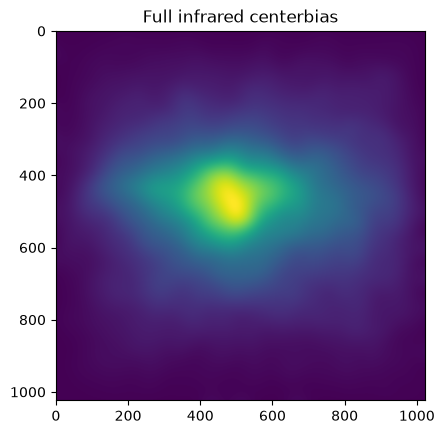

In [14]:
# Infrared
centerbias_full_infrared = build_centerbias(
    fixation_sources=[
        full_infrared_df,
    ],
    output_path=root_dir / 'single' / 'centerbias.npy',
    template_shape=(1024, 1024),
    sigma=25,
)
plt.imshow(centerbias_full_infrared)
plt.title("Full infrared centerbias")